In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import Ball, Stick, Zeppelin, Dti, BallStick, Ball2Stick, Sphere, Cylinder, SandiB, SandiW, BallStickSharedDiffusivity, Ball3StickSharedDiffusivity, MultiCompartment
from dmri.simulators.acquisition_scheme import acquisition_scheme
from dmri.simulators import WatsonStick, WatsonZeppelin,BinghamStick, BinghamZeppelin, NoddiW, NoddiB


In [3]:
from dmri.simulators.semi_global_signal_models.fiber_prior import FiberPrior, plot_voxelized_fiber_field
from dmri.simulators.semi_global_signal_models.curves3d import Spline3D, plot_splines, sample_splines
from dmri.simulators.semi_global_signal_models.global_ball_and_stick import GlobalBall, GlobalStick, GlobalBallStick

fiberPrior = FiberPrior(8,3, diameter=0.5)


In [4]:
prior_fiber = FiberPrior(9,3,0.1)
voxelized_fiber = prior_fiber.sample(jax.random.key(4))
fig, ax = plot_voxelized_fiber_field(voxelized_fiber.volume_fraction, prior_fiber.grid, voxelized_fiber.tangents,size_scale=1000, volume_opacity=0.1, curves=voxelized_fiber.curve)
fig.show()

In [5]:
voxelized_fiber = jax.jit(prior_fiber.sample)(jax.random.key(4))
volumes, tangents = voxelized_fiber.volume_fraction, voxelized_fiber.tangents

In [6]:
bvecs = jax.random.normal(jax.random.key(1), (100,3))
bvecs = bvecs / jnp.linalg.norm(bvecs, axis=-1, keepdims=True)

acq = acquisition_scheme(bvals = jnp.linspace(0, 1000, 100), bvecs = bvecs)

In [48]:
fiberField = fiberPrior.sample(jax.random.key(4))
vmap3d = lambda f: jax.vmap(jax.vmap(jax.vmap(f)))
ball = GlobalBall.from_theta(jnp.zeros((8,8,8,1)), fiber_field=fiberField)
stick = GlobalStick.from_theta(jnp.ones((8,8,8,3)), fiber_field=fiberField)
#jax.vmap(jax.vmap(jax.vmap(ball.signal_fn, in_axes=(None, 0)), in_axes=(None,0)), in_axes=(None,0))(acq, ball.lam).shape

In [53]:
jnp.max(stick.to_theta(**stick.params, fiber_field=fiberField) - 1)

Array(-1.7881393e-07, dtype=float32)

In [54]:
sim = GlobalBallStick.from_theta(jnp.ones((8,8,8,5)), fiber_field=[None,fiberField])

In [55]:
thetas_rec = sim.to_theta(sim.model_fractions, sim.model_compartments, [],fiber_field=[None,fiberField])

In [59]:
fig, ax = plot_voxelized_fiber_field(sim.model_fractions[...,0], prior_fiber.grid, threshold=0.2)
fig.show()

In [27]:
sim.signal(acq).shape

(8, 8, 8, 100)

In [24]:
fiber_mask = fiberField.volume_fraction[...] > 0.1

In [11]:
signal_ball = ball.signal(acq)
signal_stick = stick.signal(acq)

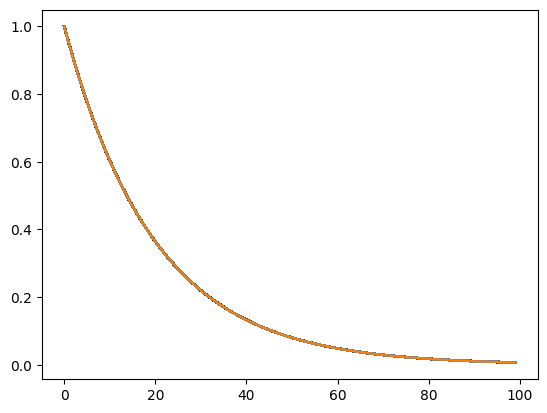

In [12]:
_ = plt.plot(signal_ball.reshape(-1,100).T)

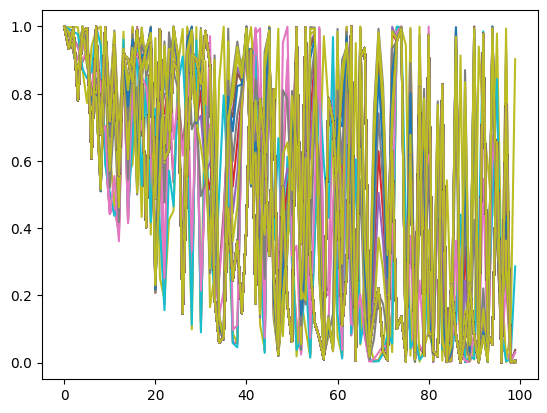

In [13]:
_ = plt.plot(signal_stick[fiber_mask].reshape(-1,100).T)

In [158]:
rng1, rng2 = jax.random.split(jax.random.key(1),2)
prior_fiber = FiberPrior(9,3,0.5)
voxelized_fiber = prior_fiber.sample(rng1)
volumes, tangents = voxelized_fiber.volume_fraction, voxelized_fiber.tangents
prior_alpha = jnp.array([1.0, 1.0])
alpha1 = 8*(1-volumes[..., None]) + prior_alpha[0]
alpha2 = 8*volumes[..., None] + prior_alpha[1]
# Simulate data
new_alpha = jnp.concat([alpha1, alpha2], axis=-1)
new_fractions = jax.random.dirichlet(rng2, new_alpha, shape=(9,9,9))
fig, _ = plot_voxelized_fiber_field(new_fractions[...,1], prior_fiber.grid, curves=voxelized_fiber.curve, threshold=0.2)
fig.show()

(array([122., 101.,  86.,  66.,  42.,  36.,  25.,  19.,  20.,   8.,   9.,
          8.,   7.,   2.,  10.,   6.,   7.,   9.,  11.,   8.,   5.,   8.,
          9.,  15.,  11.,  16.,  14.,  17.,  16.,  16.]),
 array([1.24557133e-04, 3.32793593e-02, 6.64341599e-02, 9.95889604e-02,
        1.32743761e-01, 1.65898561e-01, 1.99053362e-01, 2.32208163e-01,
        2.65362948e-01, 2.98517734e-01, 3.31672549e-01, 3.64827365e-01,
        3.97982150e-01, 4.31136936e-01, 4.64291751e-01, 4.97446567e-01,
        5.30601382e-01, 5.63756168e-01, 5.96910954e-01, 6.30065799e-01,
        6.63220584e-01, 6.96375370e-01, 7.29530215e-01, 7.62685001e-01,
        7.95839787e-01, 8.28994572e-01, 8.62149358e-01, 8.95304203e-01,
        9.28458989e-01, 9.61613774e-01, 9.94768560e-01]),
 <BarContainer object of 30 artists>)

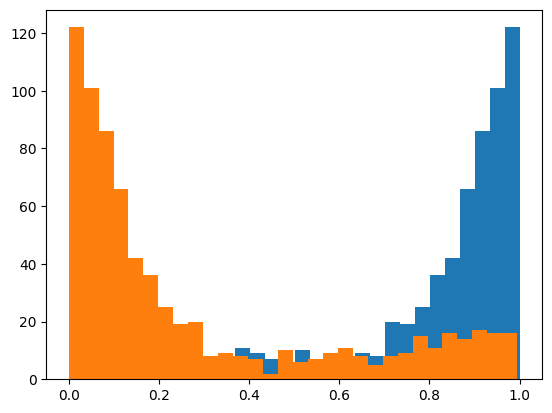

In [159]:
plt.hist(new_fractions[...,0].flatten(), bins=30)
plt.hist(new_fractions[...,1].flatten(), bins=30)

In [48]:


class FiberConditionedFractionPrior():
    """Deterministic Ball/Stick fractions conditioned on fiber presence."""

    def __init__(
        self,
        base_concentration: float = 0.5,
        fiber_bias: float = 6.0,
        volume_presence_threshold: float = 1e-4,
    ) -> None:
        super().__init__(volume_presence_threshold)
        self.base_concentration = float(base_concentration)
        self.fiber_bias = float(fiber_bias)

    def sample(self, fiber_field: FiberRepresentation, rng: jax.Array) -> jnp.ndarray:
        del rng  # Deterministic fractions; RNG kept for API compatibility
        density = self.effective_density(fiber_field.density)
        presence = density > 0.0
        logit = self.fiber_bias * (density - self.base_concentration)
        stick_fraction = jnp.where(
            presence,
            jnp.clip(jax.nn.sigmoid(logit), 1e-6, 1.0 - 1e-6),
            0.0,
        )
        ball_fraction = jnp.where(presence, 1.0 - stick_fraction, 1.0)
        ball_fraction = jnp.clip(ball_fraction, 1e-6, 1.0)
        fractions = jnp.stack([ball_fraction, stick_fraction], axis=-1)
        return fractions

NameError: name 'FiberRepresentation' is not defined

# Diffusion MRI Simulators

Based on bvals and bvecs, we can create an acquisition scheme.

In [6]:
bvals = jnp.linspace(0, 4000, 100)
bvecs = jax.random.normal(jax.random.key(0), (100, 3))
bvecs = bvecs / jnp.linalg.norm(bvecs, axis=-1, keepdims=True)

acq = acquisition_scheme(bvals, bvecs)

In [40]:
class Test(MultiCompartment):
    model_types=[Ball, Stick, Zeppelin]
    noise_types = []

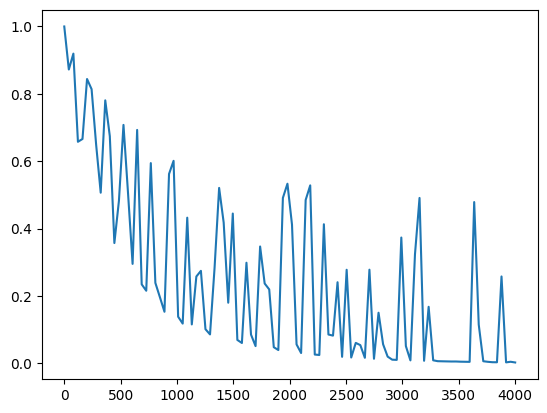

: 

In [42]:
theta = np.random.randn(Ball.theta_dim)
ball = Ball.from_theta(theta)


signal = ball.signal(acq)

plt.plot(bvals, signal)

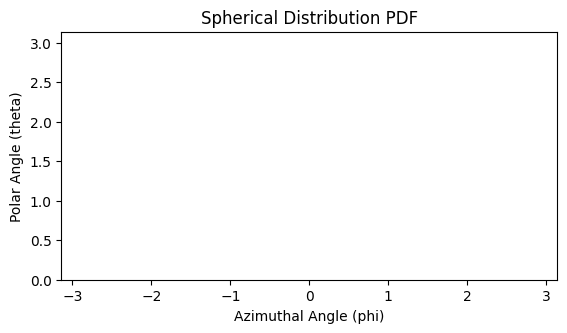

In [9]:
# Uniformly distributed signal
%matplotlib inline
ball.to_fod().viz()

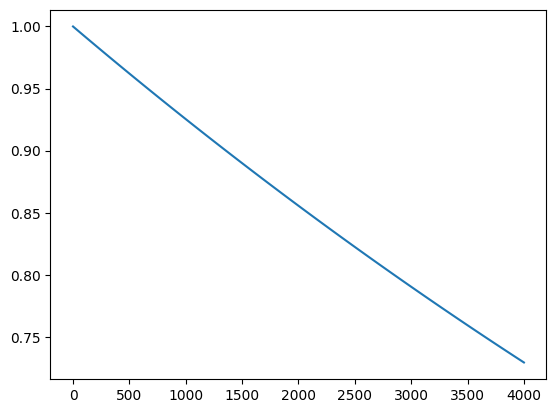

In [10]:
theta = np.random.randn(Sphere.theta_dim)
ball = Sphere.from_theta(theta)


signal = ball.signal(acq)

plt.plot(bvals, signal)

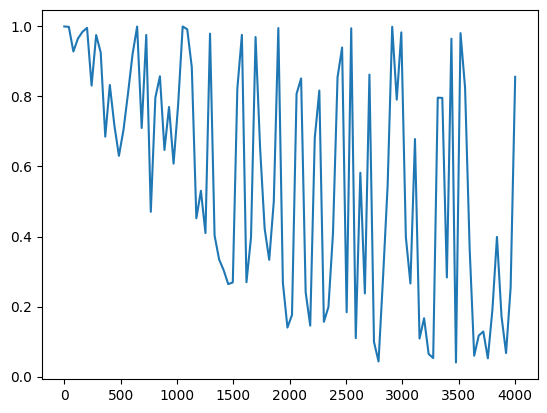

In [11]:
theta = np.random.randn(Stick.theta_dim)
stick = Stick.from_theta(theta)


signal = stick.signal(acq)

plt.plot(bvals, signal)

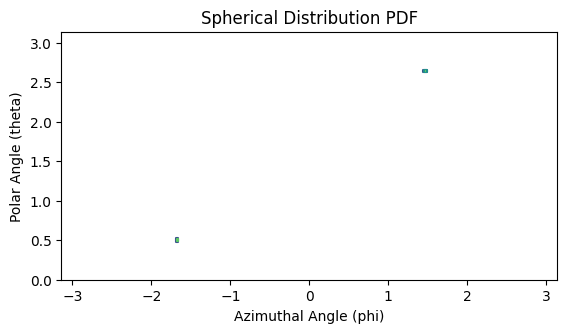

In [12]:
%matplotlib inline
theta = np.random.randn(Stick.theta_dim)
stick = Stick.from_theta(theta)
stick.to_fod().viz(plot_type='polar')

In [13]:
def stick_mu_samples(thetas):
    stick = Stick.from_theta(thetas)
    mu = stick.mu
    # Convert to cartesian
    mu = jnp.array([jnp.sin(mu[0]) * jnp.cos(mu[1]), jnp.sin(mu[0]) * jnp.sin(mu[1]), jnp.cos(mu[0])])
    return mu

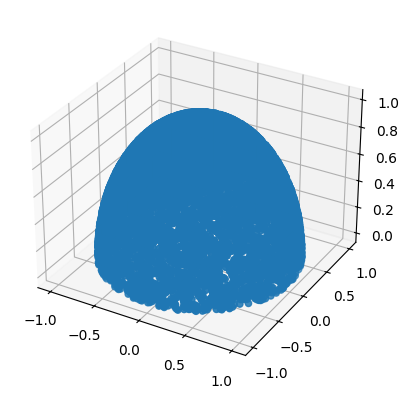

In [14]:
pos = jax.vmap(stick_mu_samples)(np.random.randn(10000, Stick.theta_dim))
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2])

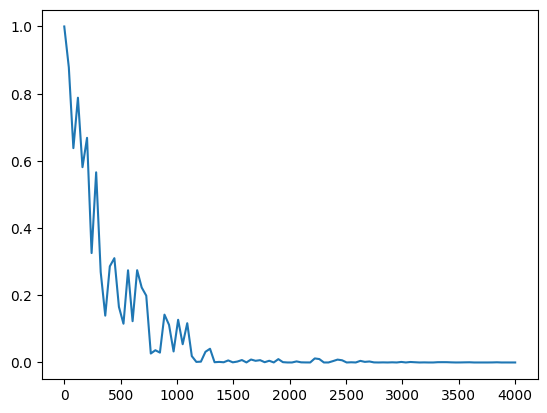

In [16]:
theta = np.random.randn(Zeppelin.theta_dim)
zep = Zeppelin.from_theta(theta)


signal = zep.signal(acq)

plt.plot(bvals, signal)

In [17]:
def stick_mu_samples(thetas):
    stick = Zeppelin.from_theta(thetas)
    mu = stick.mu
    # Convert to cartesian
    mu = jnp.array([jnp.sin(mu[0]) * jnp.cos(mu[1]), jnp.sin(mu[0]) * jnp.sin(mu[1]), jnp.cos(mu[0])])
    return mu

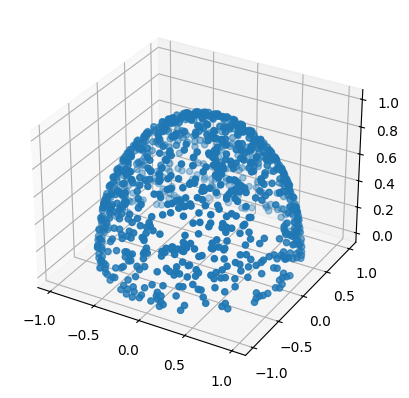

In [18]:
pos = jax.vmap(stick_mu_samples)(np.random.randn(1000, Zeppelin.theta_dim))
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2])

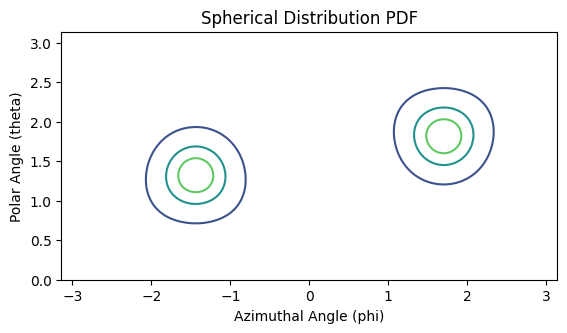

In [19]:
%matplotlib inline
theta = np.random.randn(Zeppelin.theta_dim)
zep = Zeppelin.from_theta(theta)
zep.to_fod().viz()

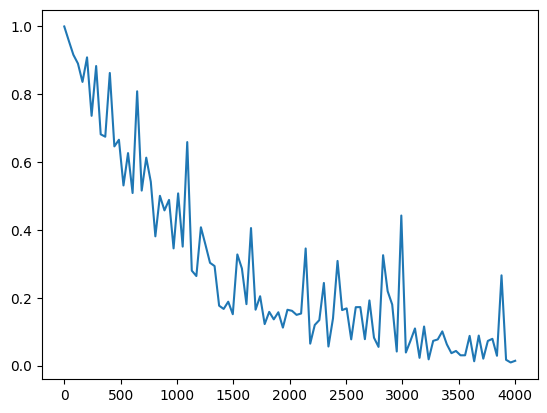

In [20]:
theta = np.random.randn(Dti.theta_dim)
dti = Dti.from_theta(theta)


signal = dti.signal(acq)

plt.plot(bvals, signal)

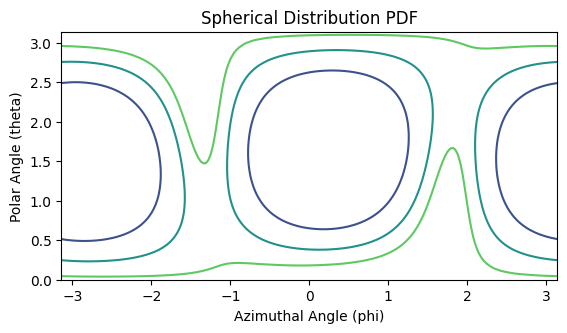

In [21]:
%matplotlib inline
dti.to_fod().viz()

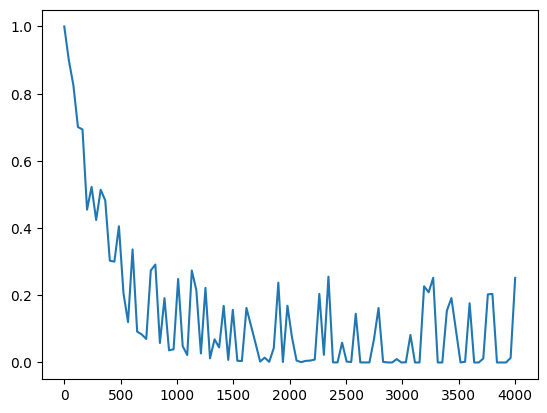

In [22]:
ball_stick = BallStick.from_theta(np.random.randn(BallStick.theta_dim))

signal = ball_stick.signal(acq, None)

plt.plot(bvals, signal)

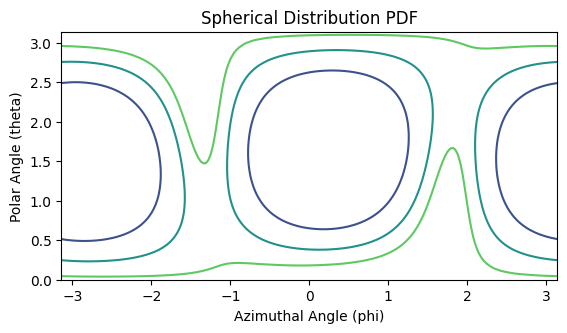

In [23]:
%matplotlib inline
dti.to_fod().viz()

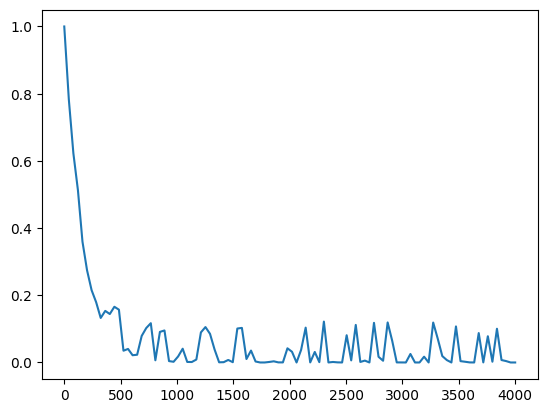

In [24]:
ball_stick_constrained = Ball3StickSharedDiffusivity.from_theta(np.random.randn(Ball3StickSharedDiffusivity.theta_dim))
signal = ball_stick_constrained.signal(acq)

plt.plot(bvals, signal)

In [25]:
ball_stick_constrained.model_compartments[1].lam_par

Array(0.00660974, dtype=float32)

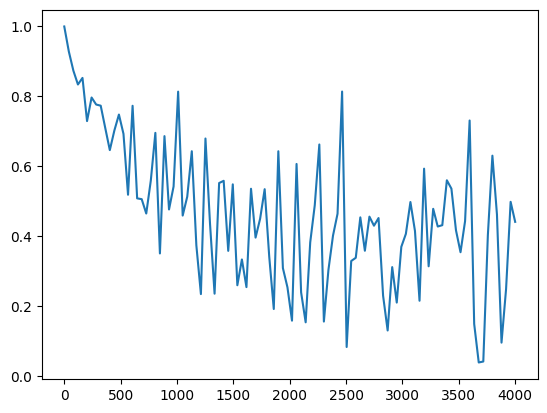

In [26]:
ball_stick = Ball2Stick.from_theta(np.random.randn(Ball2Stick.theta_dim))

signal = ball_stick.signal(acq, None)

plt.plot(bvals, signal)

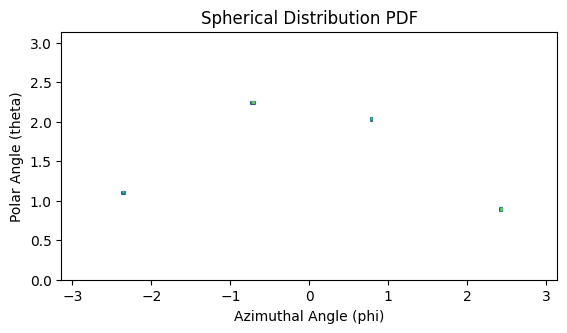

In [27]:
%matplotlib inline
ball_stick.to_fod().viz()

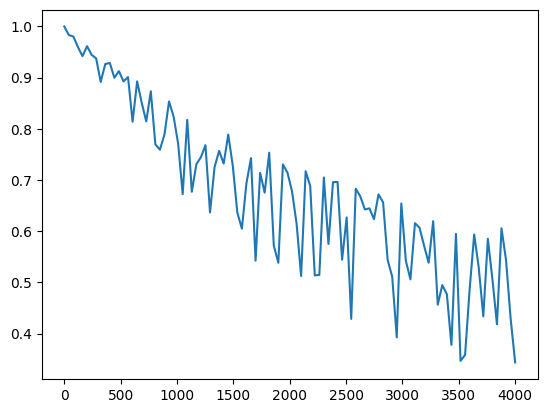

In [28]:
racket = WatsonStick.from_theta(np.random.randn(WatsonStick.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

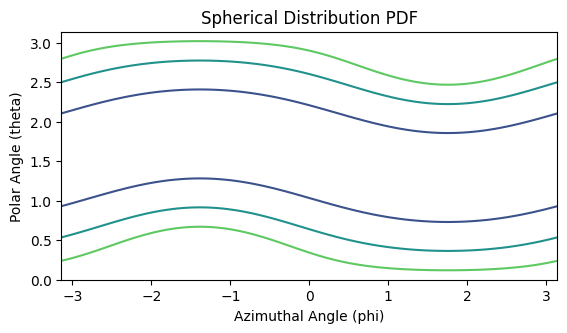

In [29]:
%matplotlib inline
racket.to_fod().viz()

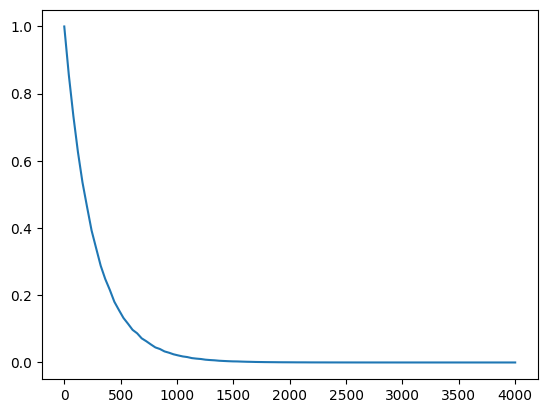

In [30]:
racket2 = WatsonZeppelin.from_theta(np.random.randn(WatsonZeppelin.theta_dim))
signal = racket2.signal(acq)
plt.plot(bvals, signal)

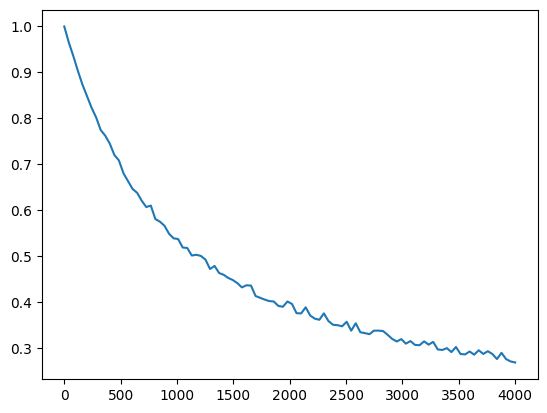

In [31]:
bracket = BinghamStick.from_theta(np.random.randn(BinghamStick.theta_dim))
signal = bracket.signal(acq)
plt.plot(bvals, signal)

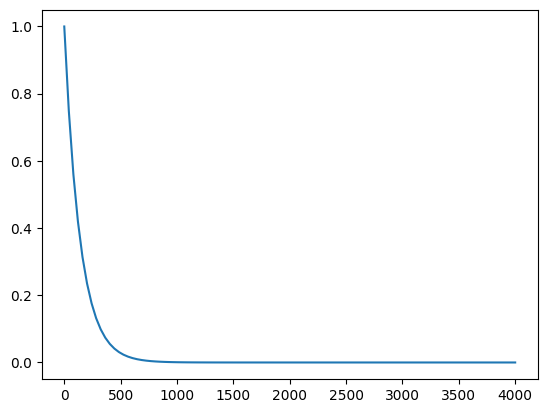

In [32]:
racket = BinghamZeppelin.from_theta(np.random.randn(BinghamStick.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

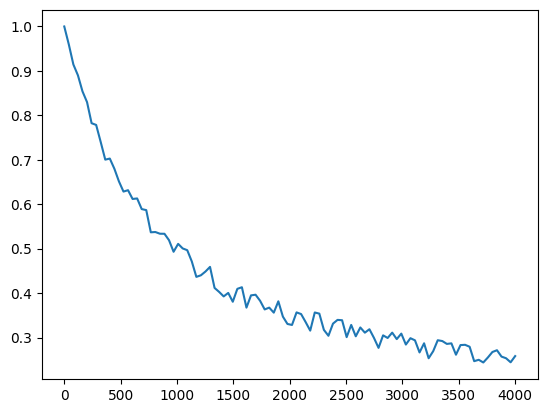

In [33]:
racket = NoddiW.from_theta(np.random.randn(NoddiW.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

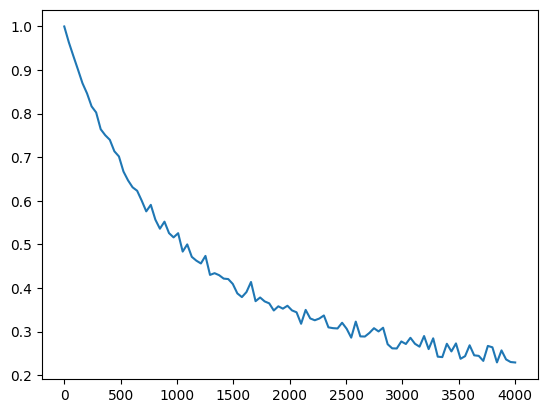

In [34]:
racket = NoddiB.from_theta(np.random.randn(NoddiB.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

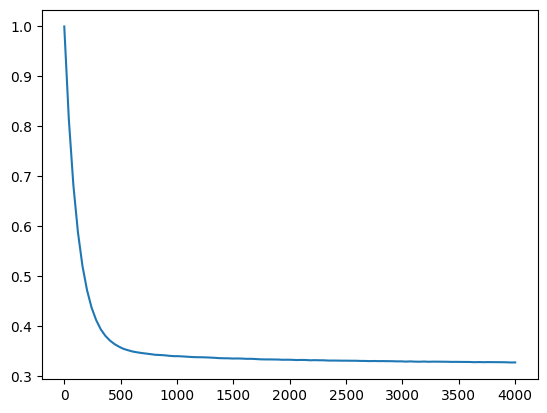

In [35]:
racket = SandiW.from_theta(np.random.randn(SandiW.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

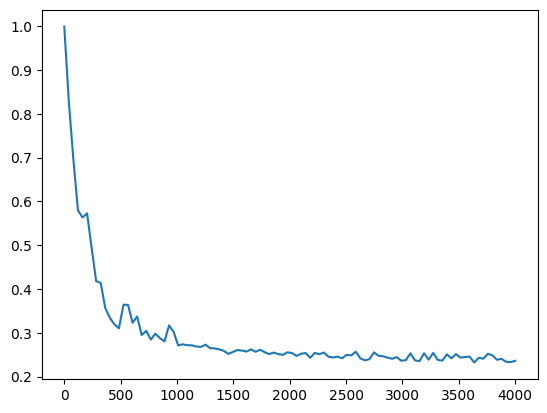

In [36]:
racket = SandiB.from_theta(np.random.randn(SandiB.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

# SSFP models

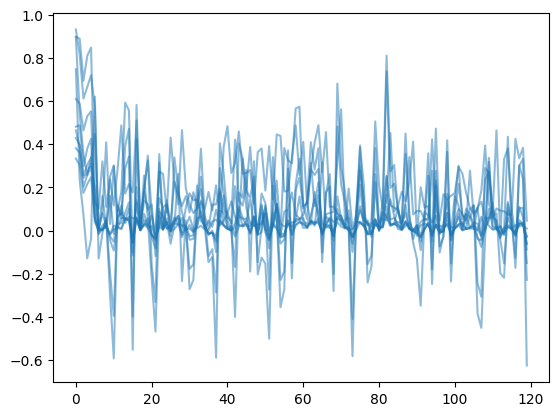

In [4]:
from dmri.simulators.local_signal_models.ball import SSFPBall
from dmri.simulators.acquisition_scheme import ssfp_acquisition_scheme, random_ssfp_acquisition
from dmri.simulators.multi_compartment import SSFPBall3StickSharedDiffusivity, Ball3StickSharedDiffusivity, SSFPBall3StickSharedDiffusivityBetterNorm


acq  = jax.jit(random_ssfp_acquisition)(jax.random.key(8))


def sim(theta):
    return SSFPBall3StickSharedDiffusivityBetterNorm.from_theta(theta).signal(acq, rng=jax.random.PRNGKey(0))

signals = jax.vmap(sim)(np.random.randn(10, SSFPBall3StickSharedDiffusivity.theta_dim))

idx = jnp.argsort(acq.qvals)
_ = plt.plot(signals[...,idx].T, color="C0", alpha=0.5)
#plt.ylim(0, 1.1)
